In [1]:
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig
from transformers import CLIPImageProcessor
# from datasets import load_dataset

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from tqdm import tqdm
import logging
import json
logger = logging.getLogger(__name__)
from pathlib import Path
import time
import copy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import plotly.graph_objects as go
from io import BytesIO
import base64

func_to_enable_grad = '_sample'
setattr(LlavaForConditionalGeneration, func_to_enable_grad, torch.enable_grad(getattr(LlavaForConditionalGeneration, func_to_enable_grad)))

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

C:\Users\Dreamcore\anaconda3\envs\fyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_id = "llava-hf/llava-1.5-7b-hf"
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    offload_state_dict=True
)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True, 
    quantization_config=quant_config,
    attn_implementation = "eager"
).to(0)

#--------------------------------------------------
model.vision_tower.config.output_attentions = True

# set hooks to get attention qkv vectors
model.qkv_vectors = {}
def make_hook(layer_name):
    def hook(module, input, output):
        # input is (hidden_states,) ; output is the projected tensor
        model.qkv_vectors[layer_name] = output.detach().cpu()
    return hook

hooks = []
for i, layer in enumerate(model.vision_tower.vision_model.encoder.layers):
    attn = layer.self_attn
    for proj_name in ['q_proj', 'k_proj', 'v_proj']:
        module = getattr(attn, proj_name)
        hook = module.register_forward_hook(make_hook(f"layer_{i}_{proj_name}"))
        hooks.append(hook)

#--------------------------------------------------

processor = AutoProcessor.from_pretrained(model_id)

if model.language_model.config.model_type == "gemma":
    eos_token_id = processor.tokenizer('<end_of_turn>', add_special_tokens=False).input_ids[0]
else:
    eos_token_id = processor.tokenizer.eos_token_id

# Define a chat history and use `apply_chat_template` to get correctly formatted prompt
# Each value in "content" has to be a list of dicts with types ("text", "image") 
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": "What is this image?"},
          {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

`torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\Dreamcore\anaconda3\envs\fyp\Lib\site-packages\transformers\modeling_utils.py:6231: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  _ = torch.empty(byte_count // factor, dtype=torch.float16, device=device, requires_grad=False)
Fetching 2 files: 100%|██████████████████████████████████████████████████████████████████████████| 2/2 [00:00<?, ?it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
# image_file = r"D:/aircraft_images/02/data/1186GMrpjP0eV7NYeK0.jpg"
# raw_image = Image.open(image_file).convert("RGB")
# inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(0, torch.float16)

# output = model.generate(
#     **inputs, 
#     max_new_tokens=1, 
#     do_sample=False,
#     use_cache=True,
#     output_attentions=True,
#     output_hidden_states=True,
#     return_dict_in_generate=True,
#     output_scores=True,
#     eos_token_id=eos_token_id
# )

# for h in hooks:
#     h.remove()

# print(processor.decode(output.sequences[0], skip_special_tokens=True))

In [4]:
# model.qkv_vectors

# Run a bunch of images and save the qkv vectors

In [5]:
folder = Path(r"D:\aircraft_images\02\data")
files = list(folder.glob("*.jpg"))[:10]   # non-recursive, get 10 images first
# or folder.rglob("*.jpg") for recursive
qkv_vectors = {}
for f in files:
    print(f"Collecting qkv vectors for image {f.as_posix()}")
    start = time.time()
    
    raw_image = Image.open(f.as_posix()).convert("RGB")
    inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(0, torch.float16)
    output = model.generate(
        **inputs, 
        max_new_tokens=1, 
        do_sample=False,
        use_cache=True,
        output_attentions=True,
        output_hidden_states=True,
        return_dict_in_generate=True,
        output_scores=True,
        eos_token_id=eos_token_id
    )
    qkv_vectors.update({f.as_posix():copy.deepcopy(model.qkv_vectors)})
    
    model.qkv_vectors.clear()
    end = time.time()
    print(f"Time taken: {end-start} seconds")
for h in hooks:
    h.remove()

Time taken: 11.602785348892212 seconds
Time taken: 21.441365480422974 seconds
Time taken: 11.47707462310791 seconds
Time taken: 20.72816753387451 seconds
Time taken: 8.09314513206482 seconds
Time taken: 20.89631962776184 seconds
Time taken: 9.27733325958252 seconds
Time taken: 20.583369731903076 seconds
Time taken: 13.536818265914917 seconds
Time taken: 21.223832368850708 seconds


In [6]:
reduced_q_vectors = {}
reduced_k_vectors = {}
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

for f in files:
    qkv_vector = qkv_vectors.get(f.as_posix())
    x = qkv_vector.get("layer_3_q_proj").cpu().numpy()[0]
    x_pca = PCA(n_components=50, random_state=42).fit_transform(x)
    x_tsne = tsne.fit_transform(x_pca)  
    reduced_q_vectors.update({f.as_posix():x_tsne})

    x = qkv_vector.get("layer_3_k_proj").cpu().numpy()[0]
    x_pca = PCA(n_components=50, random_state=42).fit_transform(x)
    x_tsne = tsne.fit_transform(x_pca)  
    reduced_k_vectors.update({f.as_posix():x_tsne})
    break

In [7]:
# fig, ax = plt.subplots(figsize=(20, 20))

# for key in reduced_q_vectors.keys():
#     img = Image.open(key)
#     oi = OffsetImage(img, zoom=0.002)
    
#     x = reduced_q_vectors.get(key)
#     ax.scatter(x[:,0], x[:,1], color="green")

#     for i in x:
#         ab = AnnotationBbox(oi, (i[0], i[1]),
#                                 xybox=(1, -1), # Adjust offset as needed
#                                 xycoords='data',
#                                 boxcoords="offset points",
#                                 pad=0.1,
#                                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
#         ax.add_artist(ab)
#         break

# for key in reduced_k_vectors.keys():
#     x = reduced_k_vectors.get(key)
#     ax.scatter(x[:,0], x[:,1], color="red")

# fig.show()

In [16]:
reduced_k_vectors

{'D:/aircraft_images/02/data/1186GMrpjP0eV7NYeK0.jpg': array([[ 29.20222   , -14.057131  ],
        [ 34.792534  ,   1.0578278 ],
        [ 35.127735  ,   0.05744964],
        ...,
        [ -0.93389285, -37.723125  ],
        [ -2.308055  , -37.13018   ],
        [ -3.399872  , -36.65819   ]], dtype=float32)}

## Resize the original image into patches for visualisation

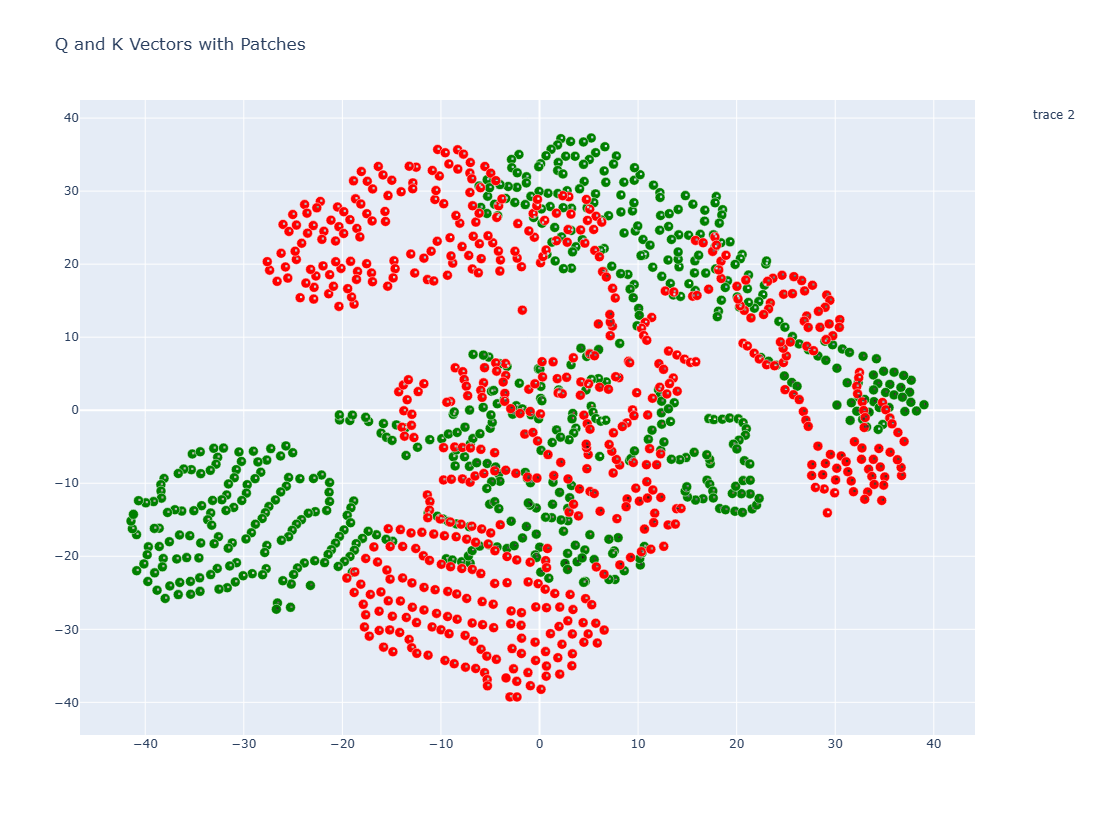

In [14]:
# Suppose you have 100 Q/K vectors reduced to 2D
X_2d_k = None
for key in reduced_k_vectors.keys():
    X_2d_k = reduced_k_vectors.get(key)

X_2d_q = None
for key in reduced_q_vectors.keys():
    X_2d_q = reduced_q_vectors.get(key)

# Create dummy patch images (replace with actual patch images)
# patch_images = [Image.new("RGB", (16, 16), color=(int(255), int(0), int(0))) for _ in range(1300)]
patch_images = []
patch_size = 14
for key in reduced_k_vectors.keys():
    img = Image.open(key).convert("RGB")
    img = img.resize((336, 336))
    img_w, img_h = img.size

    for top in range(0, img_h, patch_size):
        for left in range(0, img_w, patch_size):
            # Define box: (left, upper, right, lower)
            box = (left, top, left + patch_size, top + patch_size)
            patch = img.crop(box)
            patch_images.append(patch)

offset = 0.1

def pil_to_base64(img):
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_2d_q[:,0],
    y=X_2d_q[:,1],
    mode='markers',
    marker=dict(
        size=10,  # Adjust size as needed
        color="green",  
        line=dict(width=0.5, color='white')  # Optional border
    ),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=X_2d_k[:,0],
    y=X_2d_k[:,1],
    mode='markers',
    marker=dict(
        size=10,  # Adjust size as needed
        color="red",  
        line=dict(width=0.5, color='white')  # Optional border
    ),
    showlegend=False
))

# Add in image patches 
for x, y, patch in zip(X_2d_q[:,0], X_2d_q[:,1], patch_images):
    fig.add_layout_image(
        dict(
            source=pil_to_base64(patch),
            x=x+offset, y=y+offset,
            xref="x", yref="y",
            sizex=0.3, sizey=0.3,
            xanchor="center", yanchor="middle",
            layer="above"
        )
    )

# Add in image patches
for x, y, patch in zip(X_2d_k[:,0], X_2d_k[:,1], patch_images):
    fig.add_layout_image(
        dict(
            source=pil_to_base64(patch),
            x=x+offset, y=y+offset,
            xref="x", yref="y",
            sizex=0.3, sizey=0.3,
            xanchor="center", yanchor="middle",
            layer="above"
        )
    )

# Transparent scatter for zoom/hover
fig.add_trace(go.Scatter(
    x=np.concatenate([X_2d_q[:,0], X_2d_k[:,0]]),
    y=np.concatenate([X_2d_q[:,1], X_2d_k[:,1]]),
    mode='markers',
    marker=dict(size=2, color='rgba(0,0,0,0)')
))

fig.update_layout(width=1200, height=800, title="Q and K Vectors with Patches")
fig.show()
